In [1]:
# ── Cài đặt dependencies ─────────────────────────────────────────
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install numpy seaborn pandas matplotlib tqdm scikit-learn -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Imports & GPU check
# ════════════════════════════════════════════════════════════════
import copy, time, json, warnings, shutil
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(123)
np.random.seed(123)

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 3060
VRAM    : 12.5 GB


In [3]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Config tổng hợp (chỉ cần sửa ở đây)
# ════════════════════════════════════════════════════════════════

# ── Paths ───────────────────────────────────────────────────────
DRIVE_FOLDER = Path('/workspace/data')   # thay đường dẫn nếu cần
OUT_DIR      = Path('/workspace/zleep')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ──────────────────────────────────────────────────────
SLEEP_STAGES  = ['W', 'N1', 'N2', 'N3', 'REM']
N_CLASSES     = 5
EPOCH_SAMPLES = 3000          # 30 s × 100 Hz
N_FOLDS       = 10            # theo paper Sleep-EDF-18
MANIP_SETS    = ['A', 'B', 'C']   # đổi ['A'] để test nhanh

# ── CNN hyperparams (theo paper) ─────────────────────────────────
CNN_LR             = 1e-3
CNN_BATCH_SIZE     = 64
CNN_MAX_EPOCHS     = 1000
CNN_PATIENCE       = 10
CNN_VALIDATE_EVERY = 150      # iterations
CNN_TRAIN_RATIO    = 0.70

# ── TCN hyperparams (giữ nguyên gốc) ────────────────────────────
TCN_CHANNELS   = 128
TCN_KERNEL     = 5
TCN_BLOCKS     = 5
TCN_DROPOUT    = 0.1
TCN_LR         = 1e-3
TCN_BATCH_SIZE = 16            # sequences (records) per batch
TCN_MAX_EPOCHS = 1000
TCN_PATIENCE   = 30
TCN_VAL_EVERY  = 10           # iterations
TCN_VAL_RATIO  = 0.10
N1_BOOST       = 1
REM_BOOST      = 1
CLASS_WEIGHTS  = torch.tensor(
    [1.0, N1_BOOST, 1.0, 1.0, REM_BOOST], dtype=torch.float32
)

N_FEAT = N_CLASSES * len(MANIP_SETS) * 5   # 5 classes × 3 sets × 5 features = 75

# ── BiLSTM hyperparams (ĐÚNG PAPER) ─────────────────────────────
# Paper: Adam lr=0.01, patience=10, val_every=10, batch=4, 90/10 split
BILSTM_LR       = 1e-2   # paper dùng 0.01, KHÔNG phải 0.001
BILSTM_PATIENCE = 10     # paper dùng 10
BILSTM_VAL_EVERY = 10    # paper: validate every 10 iterations
BILSTM_MAX_EPOCHS = 1000
BILSTM_BATCH_SIZE = 4    # 4 sequences per batch (= TCN_BATCH_SIZE)
BILSTM_VAL_RATIO  = 0.10 # 90/10 split

print('✓ Config OK')
print(f'  MANIP_SETS = {MANIP_SETS}  →  {len(MANIP_SETS)*5} CNN models/fold')
print(f'  N_FEAT     = {N_FEAT}')
print(f'  OUT_DIR    = {OUT_DIR}')

✓ Config OK
  MANIP_SETS = ['A', 'B', 'C']  →  15 CNN models/fold
  N_FEAT     = 75
  OUT_DIR    = /workspace/zleep


In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Load NPZ files & xây dựng subject map
# ════════════════════════════════════════════════════════════════

def find_npz_dir(root: Path) -> Path:
    for p in sorted(root.rglob('SC*.npz')):
        return p.parent
    raise FileNotFoundError(f'Không tìm thấy file SC*.npz trong {root}')

NPZ_DIR   = find_npz_dir(DRIVE_FOLDER)
NPZ_FILES = sorted(NPZ_DIR.glob('SC*.npz'))
print(f'✓ Tìm thấy {len(NPZ_FILES)} NPZ files trong {NPZ_DIR}')

# ── Hàm normalize label ─────────────────────────────────────────
def normalize_labels(y: np.ndarray) -> np.ndarray:
    """Đảm bảo label range 0-4, rác → -1"""
    y = y.astype(np.int64).ravel()
    if y.min() == 1 and y.max() <= 5:
        y = y - 1          # shift 1-5 → 0-4
    y[(y < 0) | (y >= N_CLASSES)] = -1
    return y

# ── Load 1 NPZ file ──────────────────────────────────────────────
def load_npz(fpath: Path):
    """
    Trả về (signals, labels) đã trim 30 phút trước/sau giấc ngủ.
    signals: (T, 3000) float32
    labels:  (T,)      int64  -1=rác  0-4=valid
    """
    d    = np.load(str(fpath), allow_pickle=True)
    sigs = d['x'].astype(np.float32)
    lbls = normalize_labels(d['y'])

    if sigs.ndim == 3:
        sigs = sigs[:, 0, :]    # lấy kênh đầu tiên
    if sigs.ndim == 2 and sigs.shape[1] != EPOCH_SAMPLES:
        sigs = sigs.T           # (3000, T) → (T, 3000)

    # Trim: giữ 60 epoch trước/sau vùng ngủ
    sleep_idx = np.where((lbls >= 1) & (lbls <= 4))[0]
    if len(sleep_idx) > 0:
        s = max(0, sleep_idx[0] - 60)
        e = min(len(lbls), sleep_idx[-1] + 61)
        sigs, lbls = sigs[s:e], lbls[s:e]

    assert sigs.shape[1] == EPOCH_SAMPLES, f'shape lỗi: {sigs.shape}'
    return sigs, lbls

# ── Load tất cả records, nhóm theo subject ───────────────────────
# Subject ID: ký tự 3-4 của tên file (SC4001E0 → '00')
# Mỗi subject có thể có 2 records (2 đêm)
subject_records = defaultdict(list)   # sid → [(sigs, lbls, fname), ...]
all_records      = []

print(f'\nLoading {len(NPZ_FILES)} files ...')
print(f"{'File':<22} {'Epochs':>6} {'W':>5} {'N1':>5} {'N2':>5} {'N3':>5} {'REM':>5} {'Rác':>5}")
print('─' * 65)

for fpath in NPZ_FILES:
    try:
        sigs, lbls = load_npz(fpath)
        sid  = fpath.stem[3:5]          # '00'–'77'
        cnt  = [int((lbls == i).sum()) for i in range(N_CLASSES)]
        n_gc = int((lbls == -1).sum())
        print(f'  {fpath.name:<20} {len(lbls):>6} '
              + ' '.join(f'{c:>5}' for c in cnt)
              + f' {n_gc:>5}')
        rec = {'sid': sid, 'fname': fpath.stem,
               'sigs': sigs, 'lbls': lbls}
        subject_records[sid].append(rec)
        all_records.append(rec)
    except Exception as exc:
        print(f'  ✗ {fpath.name}: {exc}')

subject_ids = sorted(subject_records.keys())
print(f'\n✓ {len(all_records)} records  |  {len(subject_ids)} subjects')
for sid in subject_ids:
    n = len(subject_records[sid])
    ep = sum(len(r['lbls']) for r in subject_records[sid])
    print(f'  Subject {sid}: {n} record(s)  {ep} epochs')

✓ Tìm thấy 153 NPZ files trong /workspace/data

Loading 153 files ...
File                   Epochs     W    N1    N2    N3   REM   Rác
─────────────────────────────────────────────────────────────────
  SC4001E0.npz            841   188    58   250   220   125     0
  SC4002E0.npz           1127   183    59   373   297   215     0
  SC4011E0.npz           1103   157   109   562   105   170     0
  SC4012E0.npz           1186   162    92   660    96   176     0
  SC4021E0.npz           1025   128    94   545    95   163     0
  SC4022E0.npz           1009   125   184   402   119   179     0
  SC4031E0.npz            952   140    61   485    57   209     0
  SC4032E0.npz            911   136    45   400   131   199     0
  SC4041E0.npz           1235   200   166   620    53   196     0
  SC4042E0.npz           1200   185   137   514    94   270     0
  SC4051E0.npz            672   208    44   217   135    68     0
  SC4052E0.npz           1246   222   114   616   114   180     0
  SC40

In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Tạo 10-fold subject-wise split
# ════════════════════════════════════════════════════════════════

rng = np.random.default_rng(seed=123)
shuffled_ids = rng.permutation(subject_ids).tolist()
fold_groups  = np.array_split(shuffled_ids, N_FOLDS)

print(f'10-fold subject-wise CV  (seed=123)')
print()
for i, grp in enumerate(fold_groups):
    sids_list = list(grp)
    n_rec  = sum(len(subject_records[s]) for s in sids_list)
    n_ep   = sum(len(r['lbls'])
                 for s in sids_list
                 for r in subject_records[s])
    print(f'  Fold {i+1:2d}: subjects={sids_list}  '
          f'{n_rec} rec  {n_ep:,} epochs')

10-fold subject-wise CV  (seed=123)

  Fold  1: subjects=[np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]  16 rec  22,376 epochs
  Fold  2: subjects=[np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'), np.str_('40'), np.str_('49'), np.str_('31'), np.str_('38')]  16 rec  21,040 epochs
  Fold  3: subjects=[np.str_('13'), np.str_('23'), np.str_('09'), np.str_('17'), np.str_('02'), np.str_('52'), np.str_('00'), np.str_('07')]  14 rec  15,921 epochs
  Fold  4: subjects=[np.str_('34'), np.str_('53'), np.str_('59'), np.str_('32'), np.str_('48'), np.str_('20'), np.str_('66'), np.str_('55')]  16 rec  23,024 epochs
  Fold  5: subjects=[np.str_('28'), np.str_('26'), np.str_('73'), np.str_('76'), np.str_('80'), np.str_('51'), np.str_('14'), np.str_('42')]  16 rec  22,240 epochs
  Fold  6: subjects=[np.str_('04'), np.str_('30'), np.str_('56'), np.str_('19'), np.str_('18'), np.str_('67'), np.str_('43'), np.str_('24')]  1

In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Kiến trúc CNN (giống paper: ~2,500 params)
# ════════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    """Conv1D → ReLU → BatchNorm → MaxPool"""
    def __init__(self, in_ch, out_ch, kernel, pool=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel,
                      padding=kernel // 2, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(out_ch),
            nn.MaxPool1d(pool, stride=pool, ceil_mode=True),
        )
    def forward(self, x): return self.net(x)


class SleepCNN(nn.Module):
    """
    (B,1,3000)
    → CNN1 [10f, k55] → (B, 10, 188)
    → CNN2 [ 5f, k25] → (B,  5,  12)
    → Flatten(60) → Dense(10) → Dense(5) → Softmax
    Params: ~2,500
    """
    def __init__(self):
        super().__init__()
        self.cnn1    = ConvBlock(1,  10, kernel=55)
        self.cnn2    = ConvBlock(10,  5, kernel=25)
        self.head    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(60, 10), nn.ReLU(inplace=True),
            nn.Linear(10, 5),
        )
        self.softmax = nn.Softmax(dim=1)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.softmax(self.head(self.cnn2(self.cnn1(x))))


# Kiểm tra shape
_m  = SleepCNN()
_x  = torch.randn(2, 1, EPOCH_SAMPLES)
_h1 = _m.cnn1(_x); _h2 = _m.cnn2(_h1)
_n  = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'✓ SleepCNN  params={_n:,}')
print(f'  (B,1,3000) → CNN1{tuple(_h1.shape)} → CNN2{tuple(_h2.shape)} → out{tuple(_m(_x).shape)}')
assert tuple(_h1.shape[1:]) == (10, 188)
assert tuple(_h2.shape[1:]) == (5,  12)

✓ SleepCNN  params=2,495
  (B,1,3000) → CNN1(2, 10, 188) → CNN2(2, 5, 12) → out(2, 5)


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — CNN Loss (class-specific weighted CE, Eq.1-3 paper)
# ════════════════════════════════════════════════════════════════

class ClassSpecificWeightedCELoss(nn.Module):
    """
    Net_c: w_i = 0.5 / p_i
      p_i = N_c/N      (i == c)
      p_i = (N-N_c)/N  (i != c)
    class_counts tính từ tập TRAIN của fold hiện tại.
    """
    def __init__(self, target_class: int, class_counts: np.ndarray):
        super().__init__()
        N, N_c = class_counts.sum(), class_counts[target_class]
        w = np.array([
            0.5 / (N_c / N) if i == target_class
            else 0.5 / ((N - N_c) / N)
            for i in range(N_CLASSES)
        ], dtype=np.float32)
        self.register_buffer('w', torch.from_numpy(w))

    def forward(self, probs, targets):
        oh   = torch.zeros_like(probs).scatter_(1, targets.unsqueeze(1), 1.0)
        loss = -(oh * torch.log(probs + 1e-8) * self.w).sum(1)
        return loss.mean()

In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Dataset CNN (3 manipulation sets A/B/C)
# ════════════════════════════════════════════════════════════════

class EEGSleepDataset(Dataset):
    """
    Set A (Current) : x[i]   → y[i]
    Set B (Previous): x[i-1] → y[i]   (duplicate x[0] for i=0)
    Set C (Next)    : x[i+1] → y[i]   (duplicate x[-1] for i=N-1)
    Chỉ bao gồm epoch có label hợp lệ (0-4).
    """
    def __init__(self, signals: np.ndarray, labels: np.ndarray,
                 manipulation: str = 'A'):
        valid = labels != -1
        self.labels  = labels[valid].astype(np.int64)
        sigs_v       = signals[valid]
        # Áp dụng shift trên signals GỐC (toàn bộ, kể cả rác)
        # để shift đúng temporal neighbor
        if manipulation == 'A':
            self.signals = sigs_v
        elif manipulation == 'B':
            prev = np.concatenate([signals[:1], signals[:-1]], 0)
            self.signals = prev[valid]
        else:   # C
            nxt = np.concatenate([signals[1:], signals[-1:]], 0)
            self.signals = nxt[valid]

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(
            self.signals[idx].astype(np.float32)).unsqueeze(0)  # (1,3000)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

print('✓ EEGSleepDataset ready')

✓ EEGSleepDataset ready


In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Hàm train 1 CNN + extract features (per fold)
# ════════════════════════════════════════════════════════════════
class SimpleCNNDataset(Dataset):
    """Dataset cơ bản chỉ map (X, y), KHÔNG shift data vì đã shift ở vòng lặp ngoài"""
    def __init__(self, signals: np.ndarray, labels: np.ndarray):
        self.signals = signals
        self.labels = labels

    def __len__(self): 
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.signals[idx].astype(np.float32)).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y
SET_TO_MSET = {'A': 'C', 'B': 'P', 'C': 'N'}

def train_one_cnn(model, loss_fn, train_ld, val_ld, verbose=False):
    """Adam + early stopping. Trả về best model."""
    opt        = optim.Adam(model.parameters(), lr=CNN_LR)
    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())
    iteration  = 0

    model.train()
    for epoch in range(1, CNN_MAX_EPOCHS + 1):
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
            iteration += 1

            if iteration % CNN_VALIDATE_EVERY == 0:
                model.eval()
                vl, vn = 0.0, 0
                with torch.no_grad():
                    for xv, yv in val_ld:
                        xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                        vl += loss_fn(model(xv), yv).item() * yv.size(0)
                        vn += yv.size(0)
                vl /= max(vn, 1)
                model.train()

                if vl < best_loss:
                    best_loss  = vl
                    no_improve = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                    if no_improve >= CNN_PATIENCE:
                        model.load_state_dict(best_state)
                        return model
    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def extract_features_for_records(records_list, trained_cnns):
    """
    Trả về list of (features, labels) per record, GIỮ NGUYÊN sequence.
    features shape: (T, N_FEAT=75)
    labels   shape: (T,)  với -1 ở lại để filter khi eval
    """
    order = [f"{SET_TO_MSET[s]}_{st}"
             for s in MANIP_SETS for st in SLEEP_STAGES]
    manip_map = {f"{SET_TO_MSET[s]}_{st}": s
                 for s in MANIP_SETS for st in SLEEP_STAGES}

    results = []
    for rec in records_list:
        sigs = rec['sigs']    # (T, 3000)
        lbls = rec['lbls']    # (T,)
        T    = len(lbls)
        dummy_lbls = np.zeros(T, dtype=np.int64)

        cols = []
        for name in order:
            if name not in trained_cnns:
                continue
            cnn   = trained_cnns[name].to(DEVICE).eval()
            manip = manip_map[name]

            # Tạo shifted signal cho toàn record (kể cả rác)
            if manip == 'A':
                s_shifted = sigs
            elif manip == 'B':
                s_shifted = np.concatenate([sigs[:1], sigs[:-1]], 0)
            else:  # C
                s_shifted = np.concatenate([sigs[1:], sigs[-1:]], 0)

            # Feed forward toàn bộ record theo batch
            ld = DataLoader(
                _RawDataset(s_shifted),
                batch_size=256, shuffle=False
            )
            preds = [cnn(xb.to(DEVICE)).cpu().numpy() for xb in ld]
            cols.append(np.concatenate(preds, axis=0))  # (T, 5)

        feats = np.concatenate(cols, axis=1)  # (T, N_FEAT)
        results.append((feats, lbls))
    return results


class _RawDataset(Dataset):
    """Dataset đơn giản cho extract features (không cần label)."""
    def __init__(self, signals):
        self.s = signals
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        return torch.from_numpy(self.s[i].astype(np.float32)).unsqueeze(0)


def train_15_cnns(train_records, fold_idx, verbose=True):
    trained = {}
    for manip_set in MANIP_SETS:
        mset = SET_TO_MSET[manip_set]
        
        # 1. Xử lý shift TRÊN TỪNG RECORD để giữ đúng ngữ cảnh thời gian
        all_sigs_shifted = []
        all_lbls = []
        for r in train_records:
            sigs = r['sigs']
            lbls = r['lbls']
            if manip_set == 'A':
                s_shift = sigs
            elif manip_set == 'B':
                s_shift = np.concatenate([sigs[:1], sigs[:-1]], 0)
            else: # C
                s_shift = np.concatenate([sigs[1:], sigs[-1:]], 0)
            
            all_sigs_shifted.append(s_shift)
            all_lbls.append(lbls)
            
        # 2. Gộp lại
        sigs_concat = np.concatenate(all_sigs_shifted, axis=0)
        lbls_concat = np.concatenate(all_lbls, axis=0)
        
        # 3. Filter valid
        valid = lbls_concat != -1
        sigs_cnn = sigs_concat[valid]
        lbls_cnn = lbls_concat[valid]
        counts = np.bincount(lbls_cnn, minlength=N_CLASSES).astype(np.float64)
        
        # 4. Shuffle
        perm = np.random.permutation(len(lbls_cnn))
        sigs_cnn, lbls_cnn = sigs_cnn[perm], lbls_cnn[perm]
        n_tr = int(len(lbls_cnn) * CNN_TRAIN_RATIO)

        tr_ld = DataLoader(
            SimpleCNNDataset(sigs_cnn[:n_tr], lbls_cnn[:n_tr]),
            CNN_BATCH_SIZE, shuffle=True,
            num_workers=2, pin_memory=(DEVICE == 'cuda'))
        vl_ld = DataLoader(
            SimpleCNNDataset(sigs_cnn[n_tr:], lbls_cnn[n_tr:]),
            CNN_BATCH_SIZE, shuffle=False,
            num_workers=2, pin_memory=(DEVICE == 'cuda'))

        for cidx, stage in enumerate(SLEEP_STAGES):
            name = f'{mset}_{stage}'
            t0   = time.time()
            cnn  = SleepCNN().to(DEVICE)
            lf   = ClassSpecificWeightedCELoss(cidx, counts).to(DEVICE)
            best = train_one_cnn(cnn, lf, tr_ld, vl_ld)
            best.eval()
            trained[name] = best
            if verbose:
                print(f'    [{name}] ✓  {time.time()-t0:.0f}s')

    return trained

print('✓ CNN training utilities ready')

✓ CNN training utilities ready


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — TCN Model (GỮI NGUYÊN hoàn toàn từ TCN_SleepNet.ipynb)
# ════════════════════════════════════════════════════════════════

class TCNBlock(nn.Module):
    """
    1 TCN residual block:
      Conv1d(dilated) → LayerNorm → GELU → Dropout  (×2)
      + residual connection (1×1 conv nếu channel thay đổi)
    Non-causal (padding cả 2 phía) vì sleep staging là offline.
    """
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        pad = dilation * (kernel - 1) // 2
        self.conv1    = nn.Conv1d(in_ch,  out_ch, kernel,
                                  dilation=dilation, padding=pad)
        self.conv2    = nn.Conv1d(out_ch, out_ch, kernel,
                                  dilation=dilation, padding=pad)
        self.norm1    = nn.LayerNorm(out_ch)
        self.norm2    = nn.LayerNorm(out_ch)
        self.act      = nn.GELU()
        self.drop     = nn.Dropout(dropout)
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.residual(x)
        out = self.conv1(x)
        out = self.norm1(out.transpose(1, 2)).transpose(1, 2)
        out = self.act(out); out = self.drop(out)
        out = self.conv2(out)
        out = self.norm2(out.transpose(1, 2)).transpose(1, 2)
        out = self.act(out); out = self.drop(out)
        return out + res


class TCNSleepNet(nn.Module):
    """
    (B, T, N_FEAT)
    → Linear(N_FEAT → TCN_CHANNELS)
    → TCNBlock(dilation=1,2,4,8)
    → Linear(TCN_CHANNELS → N_CLASSES)
    → Softmax
    """
    def __init__(
        self,
        input_size = None,
        channels   = TCN_CHANNELS,
        kernel     = TCN_KERNEL,
        n_blocks   = TCN_BLOCKS,
        dropout    = TCN_DROPOUT,
    ):
        super().__init__()
        if input_size is None:
            input_size = N_FEAT

        self.input_proj = nn.Sequential(
            nn.Linear(input_size, channels),
            nn.LayerNorm(channels),
            nn.GELU(),
        )
        self.tcn_blocks = nn.ModuleList([
            TCNBlock(
                in_ch    = channels,
                out_ch   = channels,
                kernel   = kernel,
                dilation = 2 ** i,
                dropout  = dropout,
            )
            for i in range(n_blocks)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(channels),
            nn.Linear(channels, N_CLASSES),
        )
        self.softmax = nn.Softmax(dim=-1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)              # (B, T, C)
        x = x.transpose(1, 2)               # (B, C, T)
        for block in self.tcn_blocks:
            x = block(x)
        x = x.transpose(1, 2)               # (B, T, C)
        return self.softmax(self.classifier(x))   # (B, T, 5)


_m  = TCNSleepNet()
_x  = torch.randn(2, 100, N_FEAT)
_o  = _m(_x)
_np = sum(p.numel() for p in _m.parameters() if p.requires_grad)
_rf = (TCN_KERNEL - 1) * sum(2**i for i in range(TCN_BLOCKS)) * 2 + 1
print(f'✓ TCNSleepNet  params={_np:,}')
print(f'  {tuple(_x.shape)} → {tuple(_o.shape)}')
print(f'  Receptive field = {_rf} epochs (~{_rf*0.5:.0f} phút)')

✓ TCNSleepNet  params=833,925
  (2, 100, 75) → (2, 100, 5)
  Receptive field = 249 epochs (~124 phút)


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — TCN Dataset + Loss + Training loop (giữ nguyên gốc)
# ════════════════════════════════════════════════════════════════

class RecordDataset(Dataset):
    """Dataset theo record (sequence order), dùng cho TCN."""
    def __init__(self, feat_lbl_list):
        # feat_lbl_list: list of (feats, lbls)
        self.records = feat_lbl_list
    def __len__(self):  return len(self.records)
    def __getitem__(self, idx):
        feats, lbls = self.records[idx]
        return (torch.from_numpy(feats.astype(np.float32)),
                torch.from_numpy(lbls.astype(np.int64)))


def collate_pad(batch):
    xs, ys  = zip(*batch)
    max_len = max(x.size(0) for x in xs)
    B, F    = len(xs), xs[0].size(1)
    x_pad   = torch.zeros(B, max_len, F, dtype=torch.float32)
    y_pad   = torch.full((B, max_len), -100, dtype=torch.long)
    for i, (x, y) in enumerate(zip(xs, ys)):
        T = x.size(0)
        x_pad[i, :T] = x
        y_pad[i, :T] = y
    return x_pad, y_pad


class WeightedMaskedCELoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        # FIX: Dùng NLLLoss thay vì CrossEntropyLoss
        self.nll = nn.NLLLoss(
            weight       = class_weights,
            ignore_index = -100,
            reduction    = 'mean',
        )
    def forward(self, probs, targets):
        targets = targets.clone()
        targets[(targets == -1) | (targets < 0)] = -100
        B, T, C = probs.shape
        # Tính log(probs)
        log_p   = torch.log(probs.view(B * T, C) + 1e-8)
        # FIX: Truyền vào NLLLoss
        return self.nll(log_p, targets.view(B * T))


def train_tcn(model, tr_ld, vl_ld, loss_fn):
    opt = optim.AdamW(model.parameters(), lr=TCN_LR, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=TCN_MAX_EPOCHS, eta_min=TCN_LR * 0.01
    )
    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())
    iteration  = 0

    model.train()
    for epoch in range(1, TCN_MAX_EPOCHS + 1):
        for xb, yb in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out  = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            iteration += 1

            if iteration % TCN_VAL_EVERY == 0:
                model.eval()
                vl, vn = 0.0, 0
                with torch.no_grad():
                    for xv, yv in vl_ld:
                        xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                        vl += loss_fn(model(xv), yv).item()
                        vn += 1
                vl /= max(vn, 1)
                model.train()

                if vl < best_loss:
                    best_loss  = vl
                    no_improve = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                    if no_improve >= TCN_PATIENCE:
                        model.load_state_dict(best_state)
                        return model, epoch

        scheduler.step()
    model.load_state_dict(best_state)
    return model, TCN_MAX_EPOCHS


loss_fn_tcn = WeightedMaskedCELoss(CLASS_WEIGHTS.to(DEVICE))
print('✓ TCN training utilities ready')

✓ TCN training utilities ready


In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — Hàm evaluate TCN trên test records
# ════════════════════════════════════════════════════════════════

def evaluate_tcn(model, feat_lbl_list):
    """Trả về (preds, trues) đã filter epoch rác."""
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for feats, lbls in feat_lbl_list:
            xb   = torch.from_numpy(
                feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
            pb   = model(xb).squeeze(0).cpu().numpy()   # (T, 5)
            pred = pb.argmax(axis=1)
            valid = (lbls >= 0) & (lbls < N_CLASSES)
            all_p.append(pred[valid])
            all_t.append(lbls[valid])
    return np.concatenate(all_p), np.concatenate(all_t)


def compute_metrics(preds, trues):
    acc   = accuracy_score(trues, preds)
    mf1   = f1_score(trues, preds, average='macro',  zero_division=0)
    kappa = cohen_kappa_score(trues, preds)
    f1s   = f1_score(trues, preds, average=None,
                     labels=list(range(N_CLASSES)), zero_division=0)
    return {'acc': acc, 'mf1': mf1, 'kappa': kappa,
            **{f'f1_{s}': float(f1s[i]) for i, s in enumerate(SLEEP_STAGES)}}


def print_fold_result(fold_i, m, elapsed):
    print(f"  ✓ ACC={m['acc']*100:.2f}%  MF1={m['mf1']*100:.2f}%  "
          f"κ={m['kappa']:.4f}  "
          f"[W={m['f1_W']*100:.1f} "
          f"N1={m['f1_N1']*100:.1f} "
          f"N2={m['f1_N2']*100:.1f} "
          f"N3={m['f1_N3']*100:.1f} "
          f"REM={m['f1_REM']*100:.1f}]  "
          f"({elapsed:.0f}s)")

print('✓ Evaluation utilities ready')

✓ Evaluation utilities ready


In [13]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — MAIN LOOP: 10-Fold CV (FIXED MODEL NAME)
# ════════════════════════════════════════════════════════════════

def get_model_name(model):
    if isinstance(model, TCNSleepNet):
        return "TCN"
    else:
        return model.__class__.__name__


all_preds    = []
all_trues    = []
fold_metrics = []
fold_times   = []

# Tạo thư mục lưu checkpoint
CKPT_DIR = OUT_DIR/"weight123"
CKPT_DIR.mkdir(exist_ok=True)

print('=' * 70)
print(f'  10-Fold Subject-wise CV — ZleepAnlystNet')
print(f'  Dataset  : Sleep-EDF-18 SC  ({len(subject_ids)} subjects)')
print(f'  Protocol : Train 15CNN + Sequence Model per fold (NO data leakage)')
print(f'  Device   : {DEVICE}')
print('=' * 70)

total_t0 = time.time()

for fold_i, test_group in enumerate(fold_groups):
    fold_t0    = time.time()
    test_sids  = list(test_group)
    train_sids = [s for g in fold_groups
                    for s in g
                    if s not in test_sids]

    test_recs  = [r for s in test_sids  for r in subject_records[s]]
    train_recs = [r for s in train_sids for r in subject_records[s]]

    print(f"\n{'_'*70}")
    print(f'  FOLD {fold_i+1:2d}/{N_FOLDS}  '
          f'test subjects: {test_sids}')
    print(f'  Train: {len(train_recs)} records '
          f'({len(train_sids)} subjects)  |  '
          f'Test: {len(test_recs)} records '
          f'({len(test_sids)} subjects)')

    # ── Step 1: Load 15 CNN weights ─────────────────────────────
    fold_cnn_dir = CKPT_DIR / f'fold{fold_i+1:02d}_cnn'
    if not fold_cnn_dir.exists():
        raise FileNotFoundError(
            f'Không tìm thấy: {fold_cnn_dir}\n'
            f'Đảm bảo đã train 15CNN và lưu vào {CKPT_DIR}')

    order = [f"{SET_TO_MSET[s]}_{st}"
             for s in MANIP_SETS for st in SLEEP_STAGES]

    trained_cnns = {}
    for name in order:
        wp = fold_cnn_dir / f'{name}.pth'
        if not wp.exists():
            raise FileNotFoundError(f'Missing weight: {wp}')
        m = SleepCNN().to(DEVICE)
        m.load_state_dict(torch.load(wp, map_location=DEVICE))
        m.eval()
        trained_cnns[name] = m

    print(f'  [Step 1/4] Loaded {len(trained_cnns)} CNN weights')

    # ── Step 2: Extract train features ──────────────────────────
    print(f'\n  [Step 2/4] Extract train features ...')
    feat_t0     = time.time()
    train_feats = extract_features_for_records(train_recs, trained_cnns)

    train_feats_tcn = []
    for feats, lbls in train_feats:
        lbls_cp = lbls.copy()
        lbls_cp[lbls_cp == -1] = -100
        train_feats_tcn.append((feats, lbls_cp))

    print(f'  Features extracted: {len(train_feats_tcn)} records  '
          f'({time.time()-feat_t0:.0f}s)')

    # ── Step 3: Train sequence model ────────────────────────────
    print(f'\n  [Step 3/4] Train sequence model ...')
    tcn_t0 = time.time()

    # ── CHỌN MODEL ──────────────────────────────────────────────
    model = TCNSleepNet(input_size=N_FEAT).to(DEVICE)
    # model = BiLSTMSleepNet(input_size=N_FEAT).to(DEVICE)
    # model = TCNBiLSTMSleepNet(input_size=N_FEAT).to(DEVICE)

    model_name = get_model_name(model)
    print(f'  → Using model: {model_name}')

    _val_ratio = (TCN_VAL_RATIO)

    np.random.shuffle(train_feats_tcn)
    n_val    = max(1, int(len(train_feats_tcn) * _val_ratio))
    val_recs = train_feats_tcn[:n_val]
    tr_recs  = train_feats_tcn[n_val:]

    tr_ld = DataLoader(
        RecordDataset(tr_recs),  TCN_BATCH_SIZE,
        shuffle=True,  collate_fn=collate_pad, num_workers=0)

    vl_ld = DataLoader(
        RecordDataset(val_recs), TCN_BATCH_SIZE,
        shuffle=False, collate_fn=collate_pad, num_workers=0)

    print(f'  {model_name} train: {len(tr_recs)} rec  val: {len(val_recs)} rec')

    model, stopped_epoch = train_tcn(model, tr_ld, vl_ld, loss_fn_tcn)

    print(f'  {model_name} stopped at epoch {stopped_epoch}  '
          f'({time.time()-tcn_t0:.0f}s)')

    torch.save(model.state_dict(),
               CKPT_DIR / f'seqmodel_fold{fold_i+1:02d}.pth')

    # ── Step 4: Evaluate ────────────────────────────────────────
    print(f'\n  [Step 4/4] Evaluate on test subjects ...')
    test_feats = extract_features_for_records(test_recs, trained_cnns)
    fp, ft     = evaluate_tcn(model, test_feats)

    metrics = compute_metrics(fp, ft)
    metrics.update({
        'fold':            fold_i + 1,
        'model_name':      model_name,
        'test_subjects':   test_sids,
        'train_subjects':  train_sids,
        'n_test_epochs':   int(len(ft)),
        'n_train_records': len(train_recs),
        'stopped_epoch':   stopped_epoch,
        'fold_split_seed': 123,
        'cnn_ckpt_dir':    str(fold_cnn_dir),
        'seqmodel_ckpt':   str(CKPT_DIR / f'seqmodel_fold{fold_i+1:02d}.pth'),
    })

    fold_metrics.append(metrics)
    all_preds.extend(fp.tolist())
    all_trues.extend(ft.tolist())

    elapsed = time.time() - fold_t0
    fold_times.append(elapsed)

    print_fold_result(fold_i + 1, metrics, elapsed)

    with open(OUT_DIR / 'fold_metrics.json', 'w') as f:
        json.dump(fold_metrics, f, indent=2)

    del trained_cnns, train_feats, train_feats_tcn, test_feats, model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

total_elapsed = time.time() - total_t0
print(f'\n✓ Tổng thời gian: {total_elapsed/3600:.2f} giờ  '
      f'(avg {np.mean(fold_times)/60:.1f} phút/fold)')

  10-Fold Subject-wise CV — ZleepAnlystNet
  Dataset  : Sleep-EDF-18 SC  (78 subjects)
  Protocol : Train 15CNN + Sequence Model per fold (NO data leakage)
  Device   : cuda

______________________________________________________________________
  FOLD  1/10  test subjects: [np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]
  Train: 137 records (70 subjects)  |  Test: 16 records (8 subjects)
  [Step 1/4] Loaded 15 CNN weights

  [Step 2/4] Extract train features ...
  Features extracted: 137 records  (52s)

  [Step 3/4] Train sequence model ...
  → Using model: TCN
  TCN train: 124 rec  val: 13 rec
  TCN stopped at epoch 75  (52s)

  [Step 4/4] Evaluate on test subjects ...
  ✓ ACC=86.18%  MF1=80.67%  κ=0.8056  [W=94.7 N1=54.8 N2=88.3 N3=82.4 REM=83.1]  (111s)

______________________________________________________________________
  FOLD  2/10  test subjects: [np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL FI-1 — Đặt tên 75 features & chuẩn bị phân tích
# ════════════════════════════════════════════════════════════════
# Chạy cell này sau khi CELL 12 đã xong (CNN weights đã có).
# KHÔNG cần train TCN.

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

# ── Tên đầy đủ 75 features ───────────────────────────────────────
# Mỗi trong 15 CNN (set × target_class) xuất 5 xác suất softmax
feature_names  = []   # 75 tên chi tiết:  "C.W→N1"  = CNN(C,W), output cho N1
cnn_group_names = []  # 15 tên CNN groups: "C_W"

for s in MANIP_SETS:
    mset = SET_TO_MSET[s]
    for target in SLEEP_STAGES:
        cnn_group_names.append(f"{mset}_{target}")
        for out_cls in SLEEP_STAGES:
            feature_names.append(f"{mset}.{target}→{out_cls}")

assert len(feature_names) == N_FEAT
print(f"✓ {N_FEAT} features đã đặt tên:")
print(f"  15 CNN groups : {cnn_group_names}")
print(f"  Ví dụ (đầu)  : {feature_names[:5]}")
print(f"  Ví dụ (cuối) : {feature_names[-5:]}")

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL FI-2 — Thu thập CNN features từ TEST records (10 folds)
# ════════════════════════════════════════════════════════════════
# Không train TCN — chỉ extract features và thu thập (X_all, y_all)

X_parts, y_parts = [], []
order = [f"{SET_TO_MSET[s]}_{st}" for s in MANIP_SETS for st in SLEEP_STAGES]

print("Thu thập features từ test records ...")
print(f"{'Fold':>5} | {'Test Recs':>9} | {'Epochs':>7} | {'Time':>6}")
print("-" * 40)

t_total = time.time()

for fold_i, test_group in enumerate(fold_groups):
    t0 = time.time()
    test_sids = list(test_group)
    test_recs = [r for s in test_sids for r in subject_records[s]]

    fold_cnn_dir = CKPT_DIR / f'fold{fold_i+1:02d}_cnn'
    if not fold_cnn_dir.exists():
        raise FileNotFoundError(
            f"Không tìm thấy: {fold_cnn_dir}\n"
            "Hãy chạy cell train 15CNN trước!")

    # Load weights
    trained_cnns = {}
    for name in order:
        m = SleepCNN().to(DEVICE)
        m.load_state_dict(torch.load(fold_cnn_dir / f'{name}.pth',
                                     map_location=DEVICE))
        m.eval()
        trained_cnns[name] = m

    # Extract
    test_feats = extract_features_for_records(test_recs, trained_cnns)
    n_epochs = 0
    for feats, lbls in test_feats:
        valid = (lbls >= 0) & (lbls < N_CLASSES)
        X_parts.append(feats[valid])
        y_parts.append(lbls[valid])
        n_epochs += int(valid.sum())

    print(f"  {fold_i+1:3d}/10 | {len(test_recs):9d} | {n_epochs:7d} | {time.time()-t0:.0f}s")

    # Giải phóng GPU
    for m in trained_cnns.values(): m.cpu()
    del trained_cnns; torch.cuda.empty_cache()

X_all = np.vstack(X_parts)
y_all = np.concatenate(y_parts)

print(f"\n✓ X_all = {X_all.shape},  y_all = {y_all.shape}")
print(f"  Phân bố class: " +
      "  ".join(f"{s}={v}" for s, v in
                zip(SLEEP_STAGES, np.bincount(y_all, minlength=N_CLASSES))))
print(f"  Tổng thời gian: {(time.time()-t_total)/60:.1f} phút")

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL FI-3 — Tính Feature Importance (3 phương pháp song song)
# ════════════════════════════════════════════════════════════════
# (1) Mutual Information  — đo lượng thông tin tương hỗ feature↔label
# (2) Random Forest MDI   — mean decrease in impurity
# (3) Permutation Importance — giảm accuracy khi xáo trộn feature

def _norm01(v):
    v = np.array(v, dtype=float)
    return (v - v.min()) / (v.max() - v.min() + 1e-12)

# Subsample tối đa 60k epoch để nhanh
N_SUB = min(len(y_all), 60_000)
rng   = np.random.RandomState(123)
sub_idx = rng.choice(len(y_all), N_SUB, replace=False)
X_sub, y_sub = X_all[sub_idx], y_all[sub_idx]

# (1) Mutual Information
print("(1/3) Mutual Information ...", end=" ", flush=True)
t0 = time.time()
mi_scores = mutual_info_classif(X_sub, y_sub, discrete_features=False,
                                random_state=123)
print(f"✓ {time.time()-t0:.1f}s")

# (2) Random Forest Importance
print("(2/3) Random Forest (200 trees) ...", end=" ", flush=True)
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    n_jobs=-1, random_state=123, class_weight='balanced'
)
rf.fit(X_sub, y_sub)
rf_scores = rf.feature_importances_
print(f"✓ {time.time()-t0:.1f}s  (train acc={rf.score(X_sub, y_sub):.3f})")

# (3) Permutation Importance
print("(3/3) Permutation Importance (10 repeats) ...", end=" ", flush=True)
t0 = time.time()
perm_res  = permutation_importance(rf, X_sub, y_sub,
                                   n_repeats=10, random_state=123, n_jobs=-1)
perm_scores = perm_res.importances_mean
perm_std    = perm_res.importances_std
print(f"✓ {time.time()-t0:.1f}s")

# Chuẩn hoá & tổng hợp
mi_norm   = _norm01(mi_scores)
rf_norm   = _norm01(rf_scores)
perm_norm = _norm01(perm_scores)
ensemble_score = (mi_norm + rf_norm + perm_norm) / 3.0

# Tính importance theo CNN group (mỗi group = 5 features liên tiếp)
group_ensemble = np.array([
    ensemble_score[g*5:(g+1)*5].sum()
    for g in range(len(cnn_group_names))
])
group_ensemble_norm = _norm01(group_ensemble)

# Tính correlation matrix (phát hiện dư thừa)
print("\nTính correlation matrix 75×75 ...", end=" ", flush=True)
corr_matrix = np.corrcoef(X_all.T)
redundant_pairs = sorted(
    [(i, j, corr_matrix[i,j])
     for i in range(N_FEAT) for j in range(i+1, N_FEAT)
     if abs(corr_matrix[i,j]) > 0.95],
    key=lambda x: -abs(x[2])
)
print(f"✓  |cặp dư thừa (|r|>0.95)| = {len(redundant_pairs)}")

print("\n── Top-10 features quan trọng nhất ──")
for rank, fi in enumerate(np.argsort(ensemble_score)[::-1][:10], 1):
    print(f"  #{rank:2d}  [{fi:2d}] {feature_names[fi]:<22s} "
          f"ens={ensemble_score[fi]:.3f}  "
          f"MI={mi_norm[fi]:.3f}  RF={rf_norm[fi]:.3f}  Perm={perm_norm[fi]:.3f}")

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL FI-4 — Visualisation kết quả Feature Importance
# ════════════════════════════════════════════════════════════════

SET_COLOR = {'C': '#4C9BE8', 'P': '#E87B4C', 'N': '#5DBA72'}

fig = plt.figure(figsize=(24, 22))
fig.suptitle(
    "Feature Importance — 75 CNN Features (ZleepAnlystNet / Sleep-EDF-18)\n"
    "15 CNN models × 5 softmax outputs  |  Phương pháp: MI + RF + Permutation",
    fontsize=13, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.45, wspace=0.32,
                       left=0.07, right=0.97, top=0.94, bottom=0.04)

sort_idx = np.argsort(ensemble_score)[::-1]

# ── PLOT 1: Ensemble score tất cả 75 features ─────────────────────
ax1 = fig.add_subplot(gs[0, :])
bar_colors = [SET_COLOR[cnn_group_names[i//5][0]] for i in sort_idx]
ax1.bar(range(N_FEAT), ensemble_score[sort_idx],
        color=bar_colors, edgecolor='white', linewidth=0.25, width=0.9)
ax1.set_xticks(range(N_FEAT))
ax1.set_xticklabels([feature_names[i] for i in sort_idx],
                    rotation=90, fontsize=4.8, ha='right')
ax1.set_ylabel("Ensemble Importance (norm.)", fontsize=9)
ax1.set_title("Tất cả 75 features — sắp xếp theo Ensemble Score "
              "(xanh=Current / cam=Previous / lục=Next)", fontsize=10)
ax1.grid(axis='y', alpha=0.25)
q75 = np.percentile(ensemble_score, 75)
q25 = np.percentile(ensemble_score, 25)
ax1.axhline(ensemble_score.mean(), ls='--', color='gray',   alpha=0.7, lw=1.2,
            label=f"Mean={ensemble_score.mean():.3f}")
ax1.axhline(q75, ls='-.', color='steelblue', alpha=0.7, lw=1.2,
            label=f"Q75={q75:.3f} (ngưỡng quan trọng)")
ax1.axhline(q25, ls=':', color='tomato',     alpha=0.7, lw=1.2,
            label=f"Q25={q25:.3f} (ngưỡng dư thừa)")
ax1.legend(fontsize=8, loc='upper right')
ax1.fill_between(range(N_FEAT), q75, ensemble_score[sort_idx].clip(max=1),
                 alpha=0.08, color='steelblue')
ax1.fill_between(range(N_FEAT), 0, ensemble_score[sort_idx].clip(max=q25),
                 alpha=0.08, color='tomato')

# ── PLOT 2: Top-20, so sánh 3 phương pháp ─────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
top20 = sort_idx[:20]
x20 = np.arange(20); w = 0.25
ax2.bar(x20-w,  mi_norm[top20],   w, label='Mutual Info',   color='#4C9BE8', alpha=0.85)
ax2.bar(x20,    rf_norm[top20],   w, label='RF Importance', color='#E87B4C', alpha=0.85)
ax2.bar(x20+w, perm_norm[top20], w, label='Permutation',   color='#5DBA72', alpha=0.85)
ax2.set_xticks(x20)
ax2.set_xticklabels([feature_names[i] for i in top20], rotation=90, fontsize=6.5)
ax2.set_ylabel("Normalized Score", fontsize=9)
ax2.set_title("Top-20 Features — 3 phương pháp đánh giá", fontsize=10)
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

# ── PLOT 3: CNN Group importance (15 bars) ────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
g_order = np.argsort(group_ensemble_norm)
ax3.barh(range(15), group_ensemble_norm[g_order],
         color=[SET_COLOR[cnn_group_names[g][0]] for g in g_order],
         edgecolor='white', linewidth=0.5)
ax3.set_yticks(range(15))
ax3.set_yticklabels([cnn_group_names[g] for g in g_order], fontsize=9)
ax3.set_xlabel("Group Importance (norm.)", fontsize=9)
ax3.set_title("Importance theo CNN Group\n"
              "(mỗi bar = tổng 5 features của 1 CNN)", fontsize=10)
ax3.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
ax3.legend(handles=[Patch(color=c, label=f"{k} set")
                    for k, c in SET_COLOR.items()],
           fontsize=8, loc='lower right')

# ── PLOT 4: Correlation heatmap (reordered) ────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
corr_ro = np.abs(corr_matrix[np.ix_(sort_idx, sort_idx)])
im = ax4.imshow(corr_ro, cmap='YlOrRd', vmin=0, vmax=1,
                aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax4, shrink=0.75, label="|r|")
# Vẽ đường ngăn cách CNN groups
for g in range(1, 15):
    ax4.axhline(g*5-0.5, color='white', lw=0.4, alpha=0.5)
    ax4.axvline(g*5-0.5, color='white', lw=0.4, alpha=0.5)
ax4.set_title("Correlation Matrix |r| (sắp xếp theo importance)\n"
              "Ô đỏ đậm = features tương quan cao → dư thừa", fontsize=10)
ax4.set_xlabel("Feature index (sorted by importance)", fontsize=8)
ax4.set_ylabel("Feature index (sorted by importance)", fontsize=8)
ax4.set_xticks([]); ax4.set_yticks([])
ax4.contour(corr_ro, levels=[0.95], colors=['black'], linewidths=0.8, alpha=0.4)

# ── PLOT 5: Boxplot importance theo manipulation set ───────────────
ax5 = fig.add_subplot(gs[2, 1])
set_data = {
    'Current\n(C)':  ensemble_score[0:25],
    'Previous\n(P)': ensemble_score[25:50],
    'Next\n(N)':     ensemble_score[50:75],
}
bp = ax5.boxplot(list(set_data.values()), labels=list(set_data.keys()),
                 patch_artist=True, notch=True, widths=0.5)
for patch, color in zip(bp['boxes'], SET_COLOR.values()):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('white'); med.set_linewidth(2.5)
# Jitter points
for k, (data, color) in enumerate(zip(set_data.values(), SET_COLOR.values()), 1):
    jitter = np.random.default_rng(42).uniform(-0.18, 0.18, len(data))
    ax5.scatter(np.full(len(data), k) + jitter, data,
                alpha=0.45, s=20, color=color, edgecolors='white', lw=0.3)
ax5.set_ylabel("Ensemble Importance", fontsize=9)
ax5.set_title("Phân phối Importance theo Manipulation Set\n"
              "(Current / Previous / Next epoch)", fontsize=10)
ax5.grid(axis='y', alpha=0.3)

fi_path = OUT_DIR / 'feature_importance.png'
plt.savefig(str(fi_path), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Lưu biểu đồ: {fi_path}")

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL FI-5 — Báo cáo tổng hợp (in kết quả phân tích)
# ════════════════════════════════════════════════════════════════

q75 = np.percentile(ensemble_score, 75)
q25 = np.percentile(ensemble_score, 25)
important_idx = np.where(ensemble_score >= q75)[0]
weak_idx      = np.where(ensemble_score <= q25)[0]
medium_idx    = np.where((ensemble_score > q25) & (ensemble_score < q75))[0]

sep = "=" * 72

print(sep)
print("  BÁO CÁO FEATURE IMPORTANCE — ZleepAnlystNet (Sleep-EDF-18)")
print(sep)

print(f"\n[A] TỔNG QUAN")
print(f"    Tổng features          : {N_FEAT}")
print(f"    Subsample phân tích    : {N_SUB:,} epochs")
print(f"    RF train accuracy      : {rf.score(X_sub, y_sub)*100:.2f}%")
print(f"    Ngưỡng quan trọng (Q75): {q75:.4f}")
print(f"    Ngưỡng dư thừa    (Q25): {q25:.4f}")

print(f"\n[B] FEATURES QUAN TRỌNG (score ≥ Q75) — {len(important_idx)} features")
print(f"    {'Rank':<5} {'ID':>3}  {'Feature':<22} {'Ens':>6}  {'MI':>6}  {'RF':>6}  {'Perm':>6}")
print("    " + "-" * 60)
for rank, i in enumerate(np.argsort(ensemble_score)[::-1], 1):
    if ensemble_score[i] < q75: break
    print(f"    #{rank:<4d} [{i:2d}]  {feature_names[i]:<22} "
          f"{ensemble_score[i]:.4f}  {mi_norm[i]:.4f}  "
          f"{rf_norm[i]:.4f}  {perm_norm[i]:.4f}")

print(f"\n[C] FEATURES DƯ THỪA / YẾU (score ≤ Q25) — {len(weak_idx)} features")
print(f"    {'Rank':<5} {'ID':>3}  {'Feature':<22} {'Ens':>6}")
print("    " + "-" * 42)
for rank, i in enumerate(np.argsort(ensemble_score), 1):
    if ensemble_score[i] > q25: break
    print(f"    #{rank:<4d} [{i:2d}]  {feature_names[i]:<22} {ensemble_score[i]:.4f}")

print(f"\n[D] TƯƠNG QUAN CAO (|r| > 0.95) — {len(redundant_pairs)} cặp")
if redundant_pairs:
    print(f"    {'Feature A':<22}  {'Feature B':<22}  {'r':>6}")
    print("    " + "-" * 56)
    for i, j, c in redundant_pairs[:20]:
        print(f"    {feature_names[i]:<22}  {feature_names[j]:<22}  {c:+.4f}")
    if len(redundant_pairs) > 20:
        print(f"    ... (còn {len(redundant_pairs)-20} cặp nữa)")
else:
    print("    Không có — features đủ độc lập!")

print(f"\n[E] IMPORTANCE THEO CNN GROUP")
print(f"    {'Rank':<5} {'CNN Group':<12}  {'Score':>6}  {'Set':>8}")
print("    " + "-" * 38)
for rank, g in enumerate(np.argsort(group_ensemble_norm)[::-1], 1):
    gname = cnn_group_names[g]
    set_label = {'C': 'Current', 'P': 'Previous', 'N': 'Next'}[gname[0]]
    marker = " ✅" if rank <= 5 else (" ❌" if rank > 10 else "")
    print(f"    #{rank:<4d} {gname:<12}  {group_ensemble_norm[g]:.4f}  {set_label:<8}{marker}")

print(f"\n[F] IMPORTANCE THEO MANIPULATION SET")
for key, idx_slice, label in [
    ('Current (C)',  slice(0, 25),  'Epoch hiện tại'),
    ('Previous (P)', slice(25, 50), 'Epoch trước'),
    ('Next (N)',     slice(50, 75), 'Epoch sau'),
]:
    s = ensemble_score[idx_slice]
    print(f"    {key:<14}  mean={s.mean():.4f}  max={s.max():.4f}  min={s.min():.4f}  ({label})")

print(f"\n[G] GỢI Ý TỐI ƯU HOÁ")
n_keep = len(important_idx) + len(medium_idx)
print(f"    • Có thể thử bỏ {len(weak_idx)} features yếu → còn {n_keep} features")
weak_cnns = set(cnn_group_names[i//5] for i in weak_idx)
print(f"    • CNN groups kém hiệu quả nhất: {weak_cnns}")
if redundant_pairs:
    to_drop = set(j for _, j, _ in redundant_pairs)
    print(f"    • Có thể bỏ 1 trong mỗi cặp tương quan cao: {len(to_drop)} features ứng viên")
print(f"    • Thử tinh chỉnh: bỏ các CNN groups có group_score < 0.3")
print(sep)

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — Kết quả tổng hợp
# ════════════════════════════════════════════════════════════════

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

overall   = compute_metrics(all_preds, all_trues)

# Baseline: ZleepAnlystNet paper (Sleep-EDF-18, Fpz-Cz)
PAPER = {'acc': 84.09, 'mf1': 78.26, 'kappa': 0.7790,
         'f1_W': 93.11, 'f1_N1': 48.31, 'f1_N2': 85.86,
         'f1_N3': 81.16, 'f1_REM': 82.85}

print('\n' + '═' * 70)
print('  KẾT QUẢ — TCNSleepNet (10-fold, NO leakage) vs Paper')
print('═' * 70)
print(f"  {'Metric':<14} {'Ours':>10} {'Paper':>10} {'Diff':>10}")
print(f"  {'─'*46}")

for key, label in [('acc','Accuracy'), ('mf1','Macro F1'),
                   ('kappa','Kappa')]:
    ours  = overall[key] * 100 if key != 'kappa' else overall[key]
    paper = PAPER[key]
    diff  = (ours - paper) if key != 'kappa' else (ours - paper)
    sign  = '+' if diff >= 0 else ''
    if key == 'kappa':
        print(f"  {label:<14} {ours:>10.4f} {paper:>10.4f} {sign}{diff:>9.4f}")
    else:
        print(f"  {label:<14} {ours:>9.2f}% {paper:>9.2f}% {sign}{diff:>8.2f}%")

print(f"\n  {'Stage':<8} {'Ours':>8} {'Paper':>8} {'Diff':>8}")
print(f"  {'─'*36}")
for s in SLEEP_STAGES:
    k    = f'f1_{s}'
    ours = overall[k] * 100
    pap  = PAPER[k]
    diff = ours - pap
    sign = '+' if diff >= 0 else ''
    print(f"  {s:<8} {ours:>7.2f}% {pap:>7.2f}% {sign}{diff:>6.2f}%")

print('\n' + classification_report(
    all_trues, all_preds, target_names=SLEEP_STAGES))

# Per-fold summary
print('\n  Per-fold breakdown:')
print(f"  {'Fold':>5} {'Subjects':<15} {'ACC':>7} {'MF1':>7} {'κ':>7} "
      f"{'N_ep':>6} {'Time':>7}")
print(f"  {'─'*58}")
for m, t in zip(fold_metrics, fold_times):
    subj_str = str(m['test_subjects'][:3])
    print(f"  {m['fold']:>5} {subj_str:<15} "
          f"{m['acc']*100:>6.2f}% {m['mf1']*100:>6.2f}% "
          f"{m['kappa']:>7.4f} {m['n_test_epochs']:>6,} "
          f"{t/60:>5.1f}m")

print(f"\n  {'MEAN':>5} {'':15} "
      f"{np.mean([m['acc'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['mf1'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['kappa'] for m in fold_metrics]):>7.4f}")
print(f"  {'STD':>5} {'':15} "
      f"{np.std([m['acc']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['mf1']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['kappa'] for m in fold_metrics]):>7.4f}")


══════════════════════════════════════════════════════════════════════
  KẾT QUẢ — TCNSleepNet (10-fold, NO leakage) vs Paper
══════════════════════════════════════════════════════════════════════
  Metric               Ours      Paper       Diff
  ──────────────────────────────────────────────
  Accuracy           82.94%     84.09%    -1.15%
  Macro F1           77.08%     78.26%    -1.18%
  Kappa              0.7633     0.7790   -0.0157

  Stage        Ours    Paper     Diff
  ────────────────────────────────────
  W          92.36%   93.11%  -0.75%
  N1         47.04%   48.31%  -1.27%
  N2         85.03%   85.86%  -0.83%
  N3         79.72%   81.16%  -1.44%
  REM        81.25%   82.85%  -1.60%

              precision    recall  f1-score   support

           W       0.92      0.93      0.92     65951
          N1       0.54      0.42      0.47     21522
          N2       0.82      0.88      0.85     69132
          N3       0.82      0.78      0.80     13039
         REM       0.

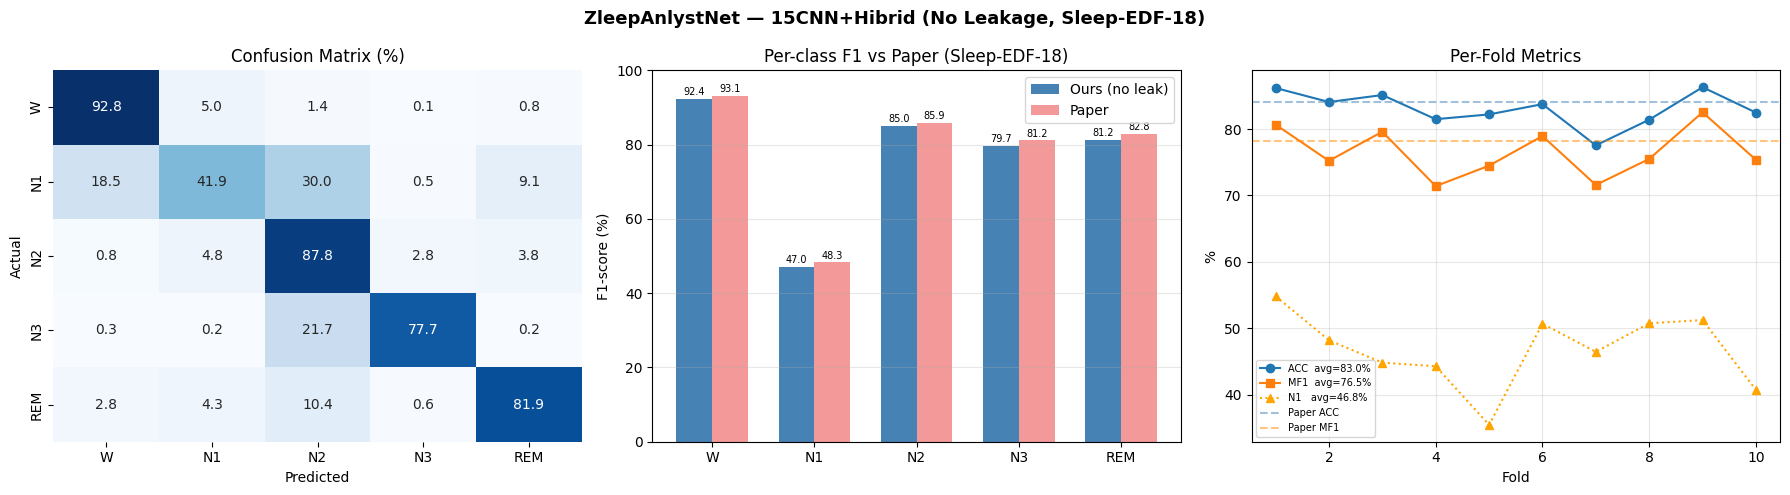

✓ Plot saved: /workspace/zleep/results.png


In [15]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Biểu đồ
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'ZleepAnlystNet — 15CNN+Hibrid (No Leakage, Sleep-EDF-18)',
    fontsize=13, fontweight='bold'
)

# ── 1. Confusion Matrix ───────────────────────────────────────
cm      = confusion_matrix(all_trues, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=SLEEP_STAGES, yticklabels=SLEEP_STAGES,
            ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix (%)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ── 2. Per-class F1: Ours vs Paper ───────────────────────────
x     = np.arange(N_CLASSES)
w     = 0.35
ours  = [overall[f'f1_{s}'] * 100 for s in SLEEP_STAGES]
paper = [PAPER[f'f1_{s}'] for s in SLEEP_STAGES]
axes[1].bar(x - w/2, ours,  w, label='Ours (no leak)',  color='steelblue')
axes[1].bar(x + w/2, paper, w, label='Paper',           color='lightcoral', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(SLEEP_STAGES)
axes[1].set_ylabel('F1-score (%)'); axes[1].set_ylim(0, 100)
axes[1].set_title('Per-class F1 vs Paper (Sleep-EDF-18)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for xi, (o, p) in enumerate(zip(ours, paper)):
    axes[1].text(xi - w/2, o + 1, f'{o:.1f}', ha='center', fontsize=7)
    axes[1].text(xi + w/2, p + 1, f'{p:.1f}', ha='center', fontsize=7)

# ── 3. Per-fold metrics ───────────────────────────────────────
folds = [m['fold']       for m in fold_metrics]
f_acc = [m['acc'] * 100  for m in fold_metrics]
f_mf1 = [m['mf1'] * 100  for m in fold_metrics]
f_n1  = [m['f1_N1'] * 100 for m in fold_metrics]
axes[2].plot(folds, f_acc, 'o-', label=f'ACC  avg={np.mean(f_acc):.1f}%')
axes[2].plot(folds, f_mf1, 's-', label=f'MF1  avg={np.mean(f_mf1):.1f}%')
axes[2].plot(folds, f_n1,  '^:', label=f'N1   avg={np.mean(f_n1):.1f}%', color='orange')
axes[2].axhline(PAPER['acc'],  color='steelblue', ls='--',   alpha=0.5, label='Paper ACC')
axes[2].axhline(PAPER['mf1'],  color='darkorange', ls='--',  alpha=0.5, label='Paper MF1')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('%')
axes[2].set_title('Per-Fold Metrics')
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = OUT_DIR / 'results.png'
plt.savefig(str(plot_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Plot saved: {plot_path}')